<a href="https://colab.research.google.com/github/Aswin661/AI-Based-Heart-Attack-Prediction-System/blob/main/Code/HeartAttack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/Patients Data ( Used for Heart Disease Prediction ).csv')
df

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PatientID                  237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df.isnull().sum()

,0
PatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
PatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [ ]:
print(df.shape)

(237630, 35)


<Axes: >

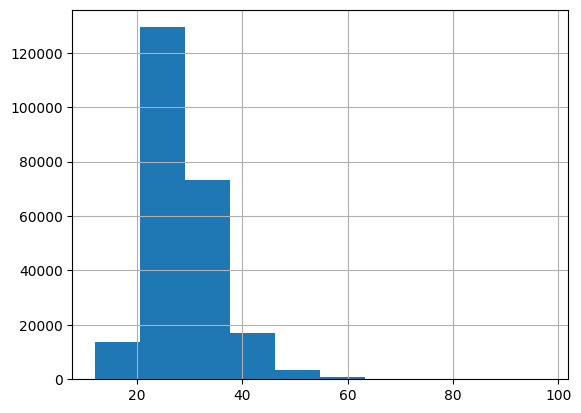

In [ ]:
df["BMI"].hist()

In [ ]:
print(df['GeneralHealth'].unique())

['Fair' 'Very good' 'Excellent' 'Good' 'Poor']


In [ ]:
df['GeneralHealth'].value_counts()

,count
GeneralHealth,
Very good,83520
Good,74950
Excellent,39911
Fair,29965
Poor,9284


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(237630, 35)

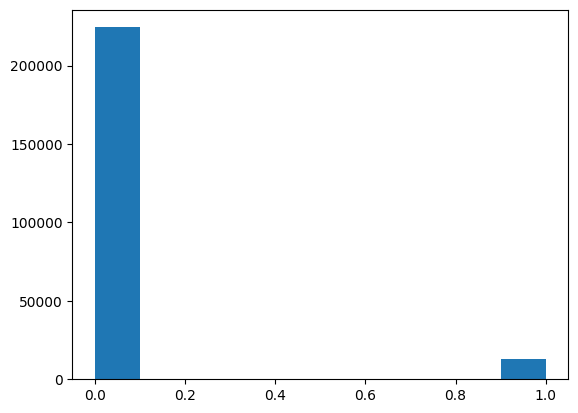

In [ ]:
plt.hist(df["HadHeartAttack"])
plt.show()

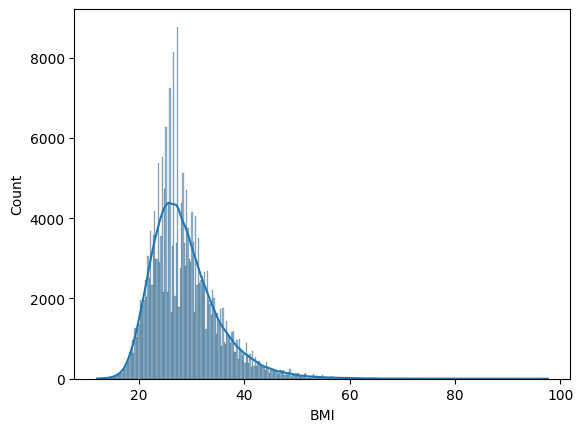

In [ ]:
sns.histplot(df['BMI'], kde=True)
plt.show()

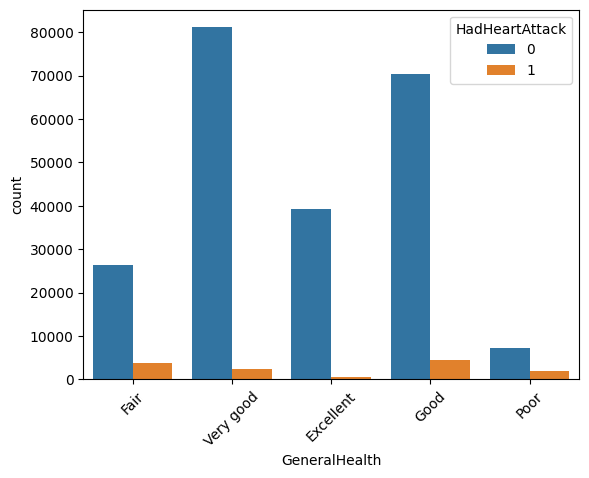

In [ ]:
sns.countplot(data=df, x='GeneralHealth', hue='HadHeartAttack')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.head()

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PatientID                  237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'State',
    'Sex',
    'GeneralHealth',
    'AgeCategory',
    'HadDiabetes',
    'SmokerStatus',
    'ECigaretteUsage',
    'RaceEthnicityCategory',
    'TetanusLast10Tdap'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,0,0,1,11,1.63,84.820000,32.099998,0,1,...,0,1,4,0,0,0,1,0,0,1
1,2,0,0,4,9,1.60,71.669998,27.990000,0,0,...,0,0,4,0,0,1,1,1,0,0
2,3,0,1,0,8,1.78,71.209999,22.530001,0,0,...,0,0,4,1,0,0,0,2,0,0
3,4,0,1,4,10,1.78,95.250000,30.129999,0,0,...,0,0,4,0,0,1,1,2,0,0
4,5,0,0,2,6,1.68,78.019997,27.760000,0,0,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,40,0,2,8,1.57,90.720001,36.580002,0,0,...,1,0,1,0,0,1,0,0,0,0
237626,237627,40,0,2,7,1.70,72.570000,25.059999,0,1,...,1,0,1,0,1,0,0,1,0,0
237627,237628,40,1,1,5,1.75,70.309998,22.889999,1,1,...,1,1,1,0,1,1,1,1,1,0
237628,237629,40,0,4,1,1.57,46.720001,18.840000,0,0,...,0,0,1,0,1,0,0,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PatientID                  237630 non-null  int64  
 1   State                      237630 non-null  int64  
 2   Sex                        237630 non-null  int64  
 3   GeneralHealth              237630 non-null  int64  
 4   AgeCategory                237630 non-null  int64  
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df.isnull().sum()

,0
PatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [ ]:
from imblearn.over_sampling import SMOTE

# Target
y = df['HadHeartAttack']

# Features
X = df.drop(columns=['HadHeartAttack'])



# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X,y)

In [ ]:
import pandas as pd
y_smote= pd.DataFrame(y_smote,columns=['HadHeartAttack'])

# Merge into one DataFrame
df_smote = pd.concat([X_smote,y_smote],axis=1)

In [ ]:
df_smote

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadAngina,HadStroke,...,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack
0,1,0,0,1,11,1.630000,84.820000,32.099998,1,0,...,1,4,0,0,0,1,0,0,1,0
1,2,0,0,4,9,1.600000,71.669998,27.990000,0,0,...,0,4,0,0,1,1,1,0,0,0
2,3,0,1,0,8,1.780000,71.209999,22.530001,0,0,...,0,4,1,0,0,0,2,0,0,0
3,4,0,1,4,10,1.780000,95.250000,30.129999,0,0,...,0,4,0,0,1,1,2,0,0,0
4,5,0,0,2,6,1.680000,78.019997,27.760000,0,0,...,1,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448853,25407,6,0,2,8,1.717087,113.741035,38.646438,0,0,...,1,4,0,0,0,0,0,0,0,1
448854,113508,25,0,2,8,1.649505,69.682911,25.887215,1,0,...,0,0,0,0,0,0,0,0,0,1
448855,223324,51,0,0,7,1.706273,80.226127,27.541835,0,0,...,1,4,0,1,0,0,0,0,0,1
448856,121076,28,0,2,7,1.656885,109.487582,39.848801,0,0,...,1,4,0,0,1,1,0,0,0,1


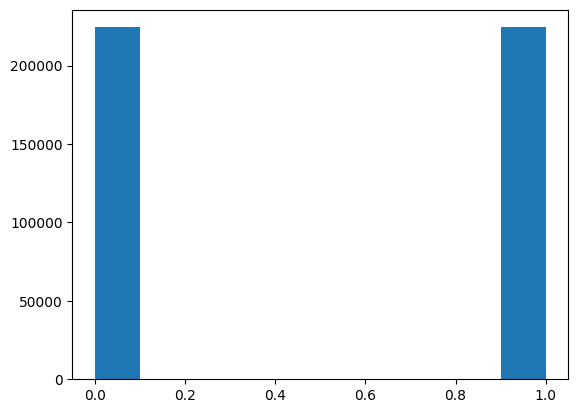

In [ ]:
plt.hist(df_smote["HadHeartAttack"])
plt.show()

In [ ]:
df_smote.drop(["PatientID", "State"], axis=1, inplace=True)

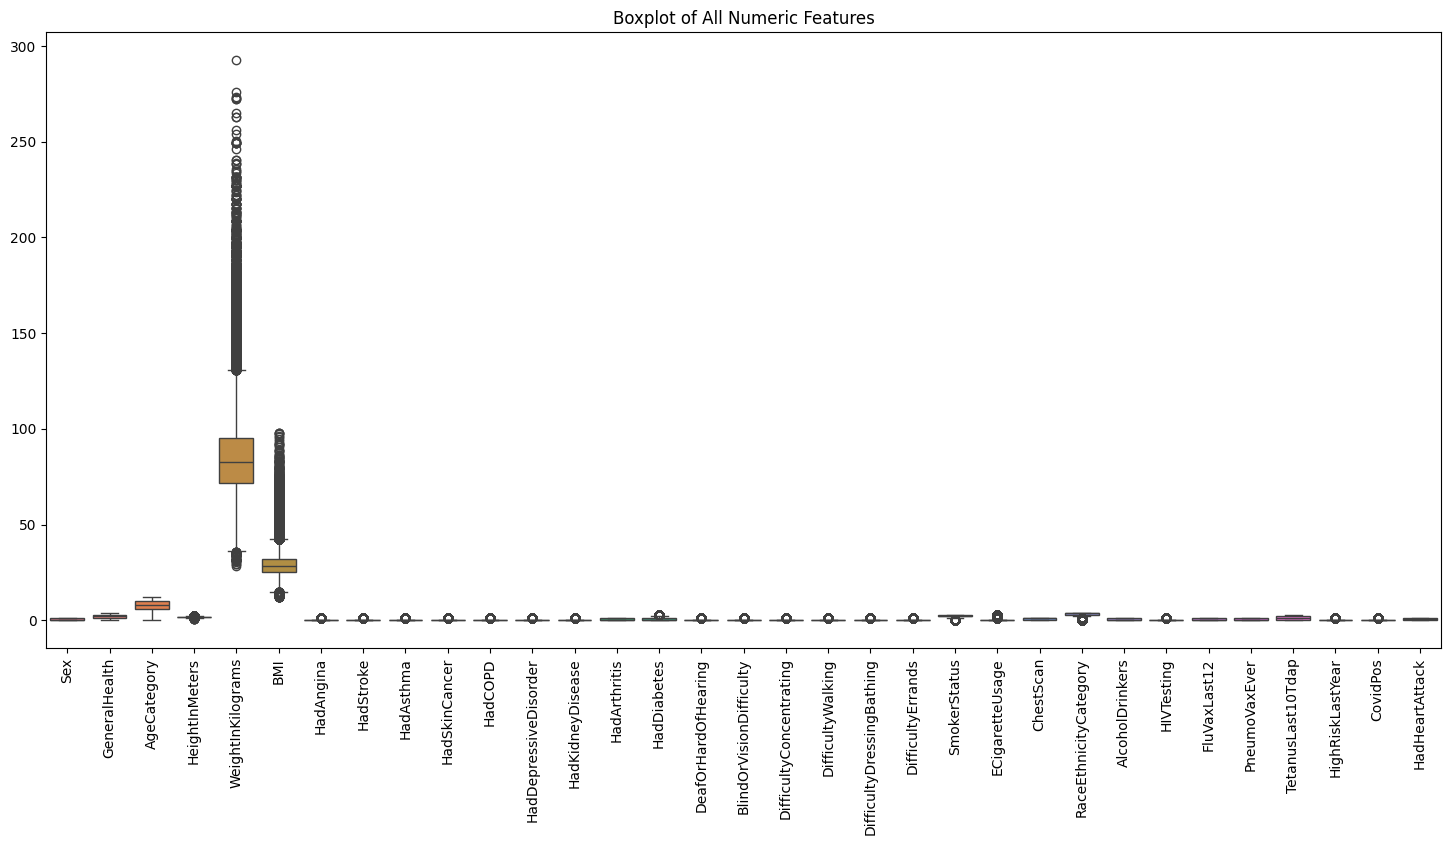

In [ ]:
numeric_df = df_smote.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(18,8))

sns.boxplot(data=numeric_df)

plt.xticks(rotation=90)
plt.title("Boxplot of All Numeric Features")
plt.show()

In [ ]:
def remove_outliers_iqr(df_smote, exclude_columns):
    df_clean = df_smote.copy()

    for col in df_clean.select_dtypes(include=['float64', 'int64']).columns:

        if col in exclude_columns:
            continue

        # skip binary columns (important fix)
        if df_clean[col].nunique() <= 2:
            continue

        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    return df_clean

In [ ]:
df_cleaned = remove_outliers_iqr(
    df_smote,
    exclude_columns=['HadHeartAttack', 'PatientID']
)

df = df_cleaned

In [ ]:
df.shape

(284160, 33)

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Select numeric features
features = ['BMI', 'HeightInMeters', 'WeightInKilograms']

# Create scaler
scaler = MinMaxScaler()

# Fit + transform
scaled_data = scaler.fit_transform(df_smote[features])

# Convert back to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=features)

scaled_df.head()

,BMI,HeightInMeters,WeightInKilograms
0,0.234497,0.480000,0.214407
1,0.186500,0.460000,0.164681
2,0.122737,0.580000,0.162942
3,0.211491,0.580000,0.253848
4,0.183814,0.513333,0.188693


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y = df_smote['HadHeartAttack']

X = df_smote.drop(columns=['HadHeartAttack', 'PatientID', 'State'], errors='ignore')

X.columns = X.columns.astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8411442320545381


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Conclusion
The class imbalance in the dataset was addressed using SMOTE (Synthetic Minority Oversampling Technique), ensuring that the model could learn patterns from both heart attack and non-heart attack cases more effectively. A Logistic Regression model was then trained on the balanced dataset to predict the occurrence of heart attacks based on patient demographic, health, and lifestyle factors. The model achieved an accuracy of **84.11%**, indicating a strong ability to distinguish between patients who have experienced a heart attack and those who have not.

These results demonstrate that machine learning can be a valuable tool for identifying individuals at elevated risk of heart attacks. While the model shows promising predictive performance, further evaluation using metrics such as precision, recall, F1-score, and ROC-AUC is recommended to ensure reliable performance in healthcare settings. With additional validation and refinement, this approach could support healthcare professionals in early risk assessment, preventive interventions, and informed clinical decision-making.
